In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import pandas as pd

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from einops import rearrange

device = torch.device("cuda")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


In [3]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2")
baseline_model.to(device)
baseline_model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
def kronecker_decompose(W, m, n, k=1):
    out_dim, in_dim = W.shape
    m2 = out_dim // m
    n2 = in_dim // n

    W_re = rearrange(
        W,
        '(m m2) (n n2) -> (m n) (m2 n2)',
        m=m, m2=m2, n=n, n2=n2
    )

    U, S, V = torch.svd_lowrank(W_re, q=k)

    A = rearrange(U, '(m n) k -> k m n', m=m, n=n)
    B = rearrange(V, '(m2 n2) k -> k m2 n2', m2=m2, n2=n2)

    scale = S.sqrt().view(-1, 1, 1)
    return A * scale, B * scale


In [5]:
def adaptive_normalize(W, A, B):
    W_hat = torch.kron(A[0], B[0])
    alpha = torch.norm(W, p="fro") / torch.norm(W_hat, p="fro")
    return A * torch.sqrt(alpha), B * torch.sqrt(alpha)


In [6]:
class KroneckerLinear(nn.Module):
    def __init__(self, A, B, bias):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone())

    def forward(self, x):
        y = torch.matmul(x, self.A)
        y = y.unsqueeze(-1) * self.B
        y = y.reshape(y.shape[0], y.shape[1], -1)
        return y + self.bias


class KroneckerLinearProj(nn.Module):
    def __init__(self, A, B, bias):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone())

    def forward(self, x):
        x = x.view(x.shape[0], x.shape[1], -1, 2)
        x = (x * self.B).sum(dim=-1)
        x = torch.matmul(x, self.A.t())
        return x + self.bias


In [7]:
def compress_one_layer(model, layer_idx):
    block = model.transformer.h[layer_idx]

    # c_fc
    W_fc = block.mlp.c_fc.weight
    b_fc = block.mlp.c_fc.bias

    A_fc, B_fc = kronecker_decompose(W_fc, m=768, n=1536)
    A_fc, B_fc = adaptive_normalize(W_fc, A_fc, B_fc)

    block.mlp.c_fc = KroneckerLinear(
        A_fc[0].to(device),
        B_fc[0].to(device),
        b_fc.to(device)
    )

    # c_proj
    W_proj = block.mlp.c_proj.weight.T
    b_proj = block.mlp.c_proj.bias

    A_p, B_p = kronecker_decompose(W_proj, m=768, n=1536)
    A_p, B_p = adaptive_normalize(W_proj, A_p, B_p)

    block.mlp.c_proj = KroneckerLinearProj(
        A_p[0].to(device),
        B_p[0].to(device),
        b_proj.to(device)
    )


In [8]:
compressed_model = GPT2LMHeadModel.from_pretrained("gpt2")
compressed_model.to(device)

for layer_idx in range(12):
    compress_one_layer(compressed_model, layer_idx)

compressed_model.eval()
print("12-layer compressed model ready.")


12-layer compressed model ready.


In [9]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")


In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding="max_length"
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format("torch")


In [11]:
small_train = tokenized_dataset["train"].select(range(2000))
small_eval = tokenized_dataset["validation"].select(range(500))

train_loader = DataLoader(small_train, batch_size=16, shuffle=True)
eval_loader = DataLoader(small_eval, batch_size=16)


In [12]:
def evaluate_perplexity(model, dataloader):
    model.eval()
    total_loss = 0
    total_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            total_batches += 1

    avg_loss = total_loss / total_batches
    return math.exp(avg_loss)


In [13]:
ppl_before = evaluate_perplexity(compressed_model, eval_loader)
print("Compressed model perplexity (before training):", ppl_before)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Compressed model perplexity (before training): 30952.871342668983


In [14]:
from torch.amp import autocast, GradScaler

optimizer = AdamW(compressed_model.parameters(), lr=3e-5)
scaler = GradScaler(device="cuda")

compressed_model.train()

for epoch in range(2):
    total_loss = 0
    steps = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = compressed_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps += 1

    print(f"Epoch {epoch+1}, Avg Loss: {total_loss/steps}")


Epoch 1, Avg Loss: 7.05801118850708
Epoch 2, Avg Loss: 5.539780513763428


In [15]:
ppl_after = evaluate_perplexity(compressed_model, eval_loader)
print("Compressed model perplexity (after training):", ppl_after)


Compressed model perplexity (after training): 301.1731418814292


In [16]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)
print("Original GPT-2 perplexity:", baseline_ppl)


Original GPT-2 perplexity: 60.27171013912783


In [17]:
import pandas as pd

results_table = pd.DataFrame({
    "Model": [
        "Original GPT-2",
        "Compressed (Before Training)",
        "Compressed (After Training)"
    ],
    "Perplexity": [
        baseline_ppl,
        ppl_before,
        ppl_after
    ]
})

results_table


,Model,Perplexity
0,Original GPT-2,60.271710
1,Compressed (Before Training),30952.871343
2,Compressed (After Training),301.173142


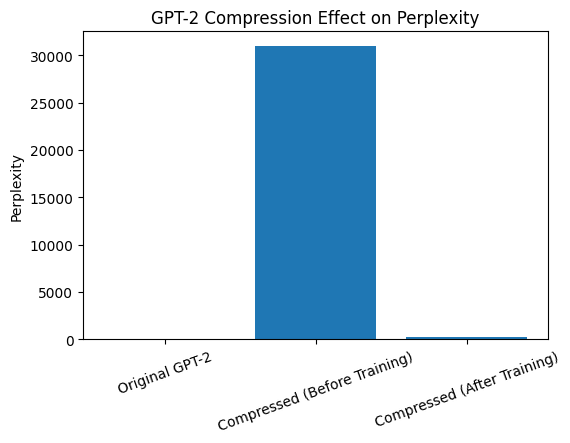

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_table["Model"], results_table["Perplexity"])
plt.xticks(rotation=20)
plt.ylabel("Perplexity")
plt.title("GPT-2 Compression Effect on Perplexity")
plt.show()


In [19]:
loss_history = []

compressed_model.train()

for epoch in range(5):   # increase to 5 epochs
    total_loss = 0
    steps = 0
    
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = compressed_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / steps
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss}")


Epoch 1, Avg Loss: 4.926218738555908
Epoch 2, Avg Loss: 4.479303657531738
Epoch 3, Avg Loss: 4.118450616836548
Epoch 4, Avg Loss: 3.773379737854004
Epoch 5, Avg Loss: 3.464308246612549


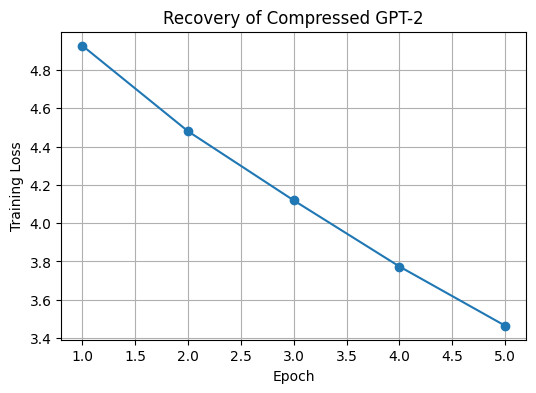

In [20]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Recovery of Compressed GPT-2")
plt.grid(True)
plt.show()


In [21]:
# Create fresh GPT-2 baseline
compressed_6 = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
compressed_6.eval()

# Compress only first 6 layers
for layer_idx in range(6):
    compress_one_layer(compressed_6, layer_idx)

print("Compressed first 6 FFN layers.")


Compressed first 6 FFN layers.


In [22]:
ppl_6_before = evaluate_perplexity(compressed_6, eval_loader)
print("6-layer compressed perplexity (before training):", ppl_6_before)


6-layer compressed perplexity (before training): 85386.48368966515


In [ ]:
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

optimizer = AdamW(compressed_6.parameters(), lr=3e-5)
scaler = GradScaler(device="cuda")

compressed_6.train()

loss_history_6 = []

for epoch in range(5):
    total_loss = 0
    steps = 0
    
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = compressed_6(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / steps
    loss_history_6.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss}")


Epoch 1, Avg Loss: 6.055915058135986


In [ ]:
ppl_6_after = evaluate_perplexity(compressed_6, eval_loader)
print("6-layer compressed perplexity (after training):", ppl_6_after)


In [ ]:
results_extended = pd.DataFrame({
    "Model": [
        "Original GPT-2",
        "12-layer compressed (after train)",
        "6-layer compressed (after train)"
    ],
    "Perplexity": [
        baseline_ppl,
        ppl_after,
        ppl_6_after
    ]
})

results_extended


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(results_extended["Model"], results_extended["Perplexity"])
plt.xticks(rotation=20)
plt.ylabel("Perplexity")
plt.title("Compression Depth vs Perplexity")
plt.show()
